In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [90]:
df1 = pd.read_csv("finally.csv")

In [91]:
df = df1.copy()

In [92]:
df.head()

,CUSTOMER_ID,TOTAL_SPENDING,FREQUENCY,RETURN_RATIO,PURCHASE_INTENSITY,AVG_ORDER_VALUE,AVG_PURCHASE_GAP,ONE_TIME_CUSTOMER
0,12346.0,270.40,1,0.500000,6.000000,45.066667,45.000000,1
1,12747.0,59992.40,11,0.071730,21.545455,253.132489,36.300000,0
2,12748.0,1839408.35,216,0.068624,50.462963,168.753060,1.382488,0
3,12749.0,169590.85,7,0.061144,72.428571,334.498718,29.428571,0
4,12820.0,13109.20,4,0.093458,26.750000,122.515888,107.333333,0


<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

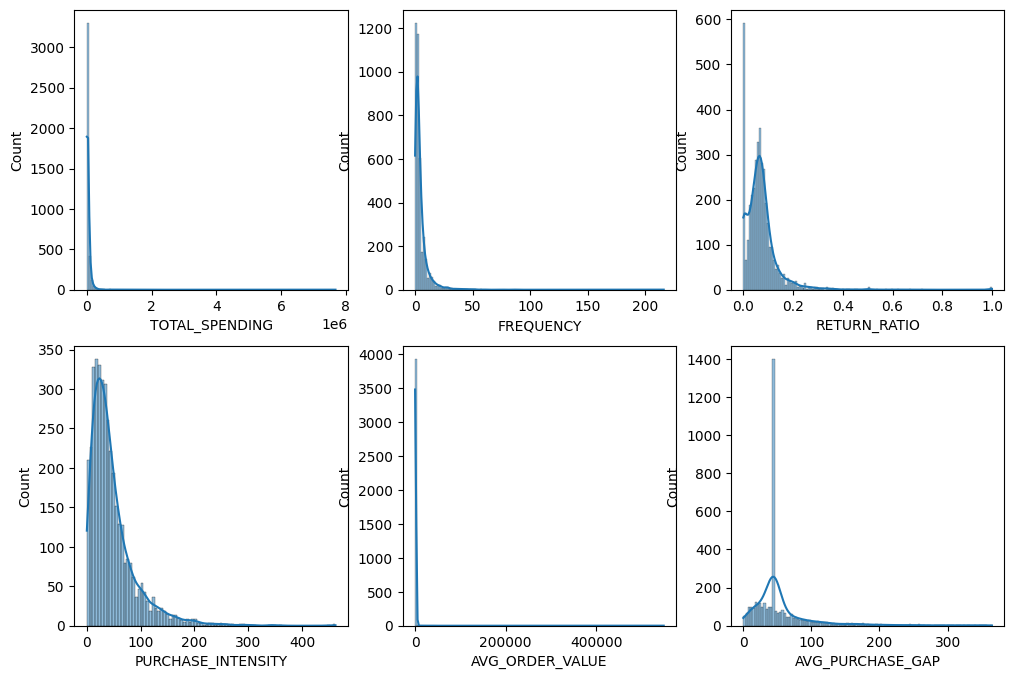

In [93]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df["AVG_PURCHASE_GAP"],kde = True)

In [114]:

cols = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'AVG_ORDER_VALUE',
    'AVG_PURCHASE_GAP'
]

for col in cols:
    lower = df[col].quantile(0.01)   
    upper = df[col].quantile(0.99)   

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

df["PURCHASE_INTENSIT"] = np.sqrt(df["PURCHASE_INTENSITY"])

<Axes: xlabel='AVG_PURCHASE_GAP', ylabel='Count'>

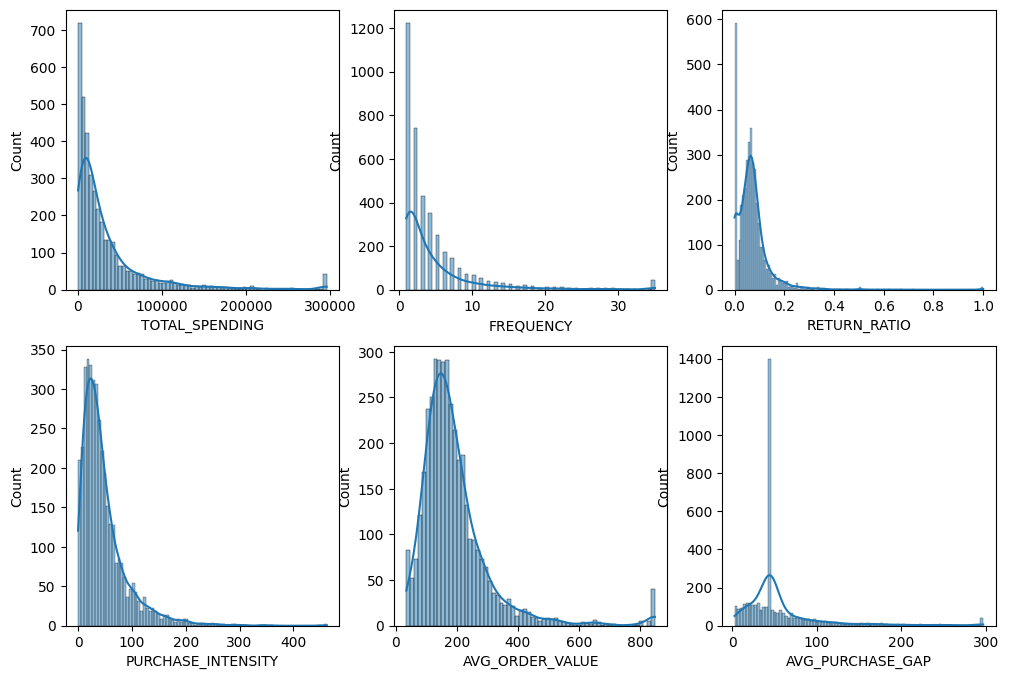

In [95]:
plt.figure(figsize=(12, 8))
plt.subplot(2,3,1)
sns.histplot(df["TOTAL_SPENDING"], kde = True)
plt.subplot(2,3,2)
sns.histplot(df["FREQUENCY"],kde = True)
plt.subplot(2,3,3)
sns.histplot(df["RETURN_RATIO"],kde = True)
plt.subplot(2,3,4)
sns.histplot(df["PURCHASE_INTENSITY"],kde = True)
plt.subplot(2,3,5)
sns.histplot(df["AVG_ORDER_VALUE"],kde = True)
plt.subplot(2,3,6)
sns.histplot(df["AVG_PURCHASE_GAP"],kde = True)

In [96]:
 features = [ 'FREQUENCY', 'TOTAL_SPENDING',  'AVG_ORDER_VALUE','AVG_PURCHASE_GAP']

In [97]:
X = df[features]

In [98]:
ss = StandardScaler()
X_scaled = ss.fit_transform(X)

In [99]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

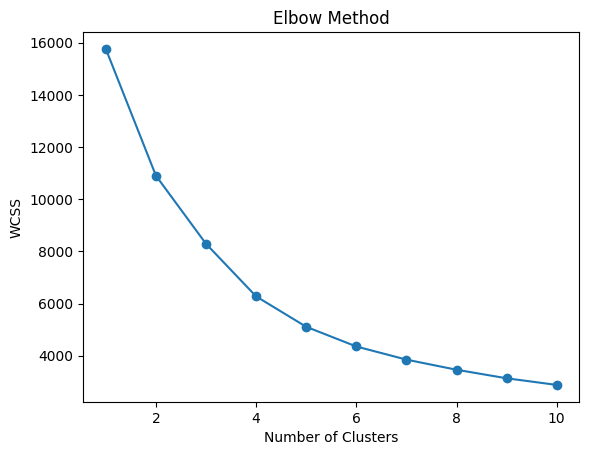

In [100]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")


In [113]:
k = 4  

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [102]:
score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.4864130543420066


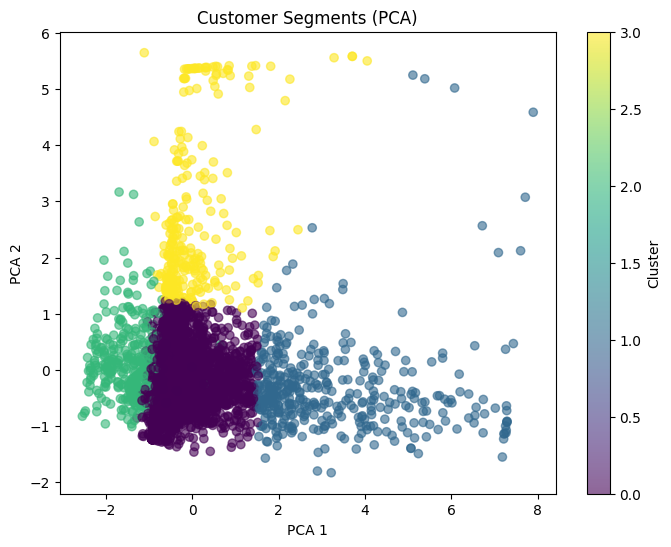

In [103]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [104]:
cluster_summary = df.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         FREQUENCY  TOTAL_SPENDING  AVG_ORDER_VALUE  AVG_PURCHASE_GAP
Cluster                                                              
0         3.266757    22602.830711       164.451028         48.016317
1        17.880000   145715.612575       196.976344         22.246888
2         2.266254    19158.782802       177.433194        197.574303
3         2.376344    28612.698996       513.067449         46.677868
